In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import platform

In [2]:
if platform.system() == 'Windows':
    plt.rc('font', family = 'Malgun Gothic')

In [4]:
df = pd.read_csv('../csv/AAPL.csv')

In [5]:
# read_csv()에서 특정 컬러의 데이터만 가져온다.
# usecols 매개변수를 이용 → 사용할 컬럼들을 선택 (데이터 파일에 불필요한 컬럼들이 너무 많은 경우)

df2 = pd.read_csv('../csv/aapl.csv', usecols=['Date', 'Adj Close'])

In [6]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 9715 entries, 0 to 9714
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9715 non-null   str    
 1   Adj Close  9714 non-null   float64
dtypes: float64(1), str(1)
memory usage: 151.9 KB


In [7]:
# 결측치가 포함된 인덱스를 제거 → dropna
df2.dropna(inplace=True)

In [8]:
df2.head(1)

,Date,Adj Close
0,1980-12-12,0.410525


In [9]:
# Date → 시계열 변경

df2['Date'] = pd.to_datetime(df2['Date'])
df2.info()

<class 'pandas.DataFrame'>
Index: 9714 entries, 0 to 9714
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       9714 non-null   datetime64[us]
 1   Adj Close  9714 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 227.7 KB


In [10]:
df2.set_index('Date', inplace=True)

- 이동평균선
    - n일치 주가의 평균을 구한다.

In [11]:
# 인덱스를 n개씩 묶어서 Adj Close의 평균을 구한다.
df2.iloc[0:20, 0].mean()

np.float64(0.4432777)

In [19]:
# 이동평균값 컬럼을 먼저 생성 → 데이터는 0을 대입
df2['이동평균값'] = 0.0

In [20]:
df2.head()

,Adj Close,이동평균값
Date,,
1980-12-12,0.410525,0.0
1980-12-15,0.389106,0.0
1980-12-16,0.360548,0.0
1980-12-17,0.369472,0.0
1980-12-18,0.380182,0.0


In [21]:
df2.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 9714 entries, 1980-12-12 to 2019-06-24
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  9714 non-null   float64
 1   이동평균값      9714 non-null   float64
dtypes: float64(2)
memory usage: 227.7 KB


In [22]:
len(df2)-19

9695

In [23]:
df2.iloc[0:20, 0]

Date
1980-12-12    0.410525
1980-12-15    0.389106
1980-12-16    0.360548
1980-12-17    0.369472
1980-12-18    0.380182
1980-12-19    0.403385
1980-12-22    0.423019
1980-12-23    0.440868
1980-12-24    0.464072
1980-12-26    0.506909
1980-12-29    0.514049
1980-12-30    0.501554
1980-12-31    0.487276
1981-01-02    0.492630
1981-01-05    0.481921
1981-01-06    0.460502
1981-01-07    0.440868
1981-01-08    0.431944
1981-01-09    0.455147
1981-01-12    0.451577
Name: Adj Close, dtype: float64

In [24]:
for i in range(len(df2)-19):
    df2.iloc[i+19, 1] = df2.iloc[i:i+20, 0].mean()

In [26]:
# 인덱스끼리 묶어서 연산을 해주는 함수가 존재: rolling(n)
df2['center2'] = df2['Adj Close'].rolling(20).mean().fillna(0)

<Axes: xlabel='Date'>

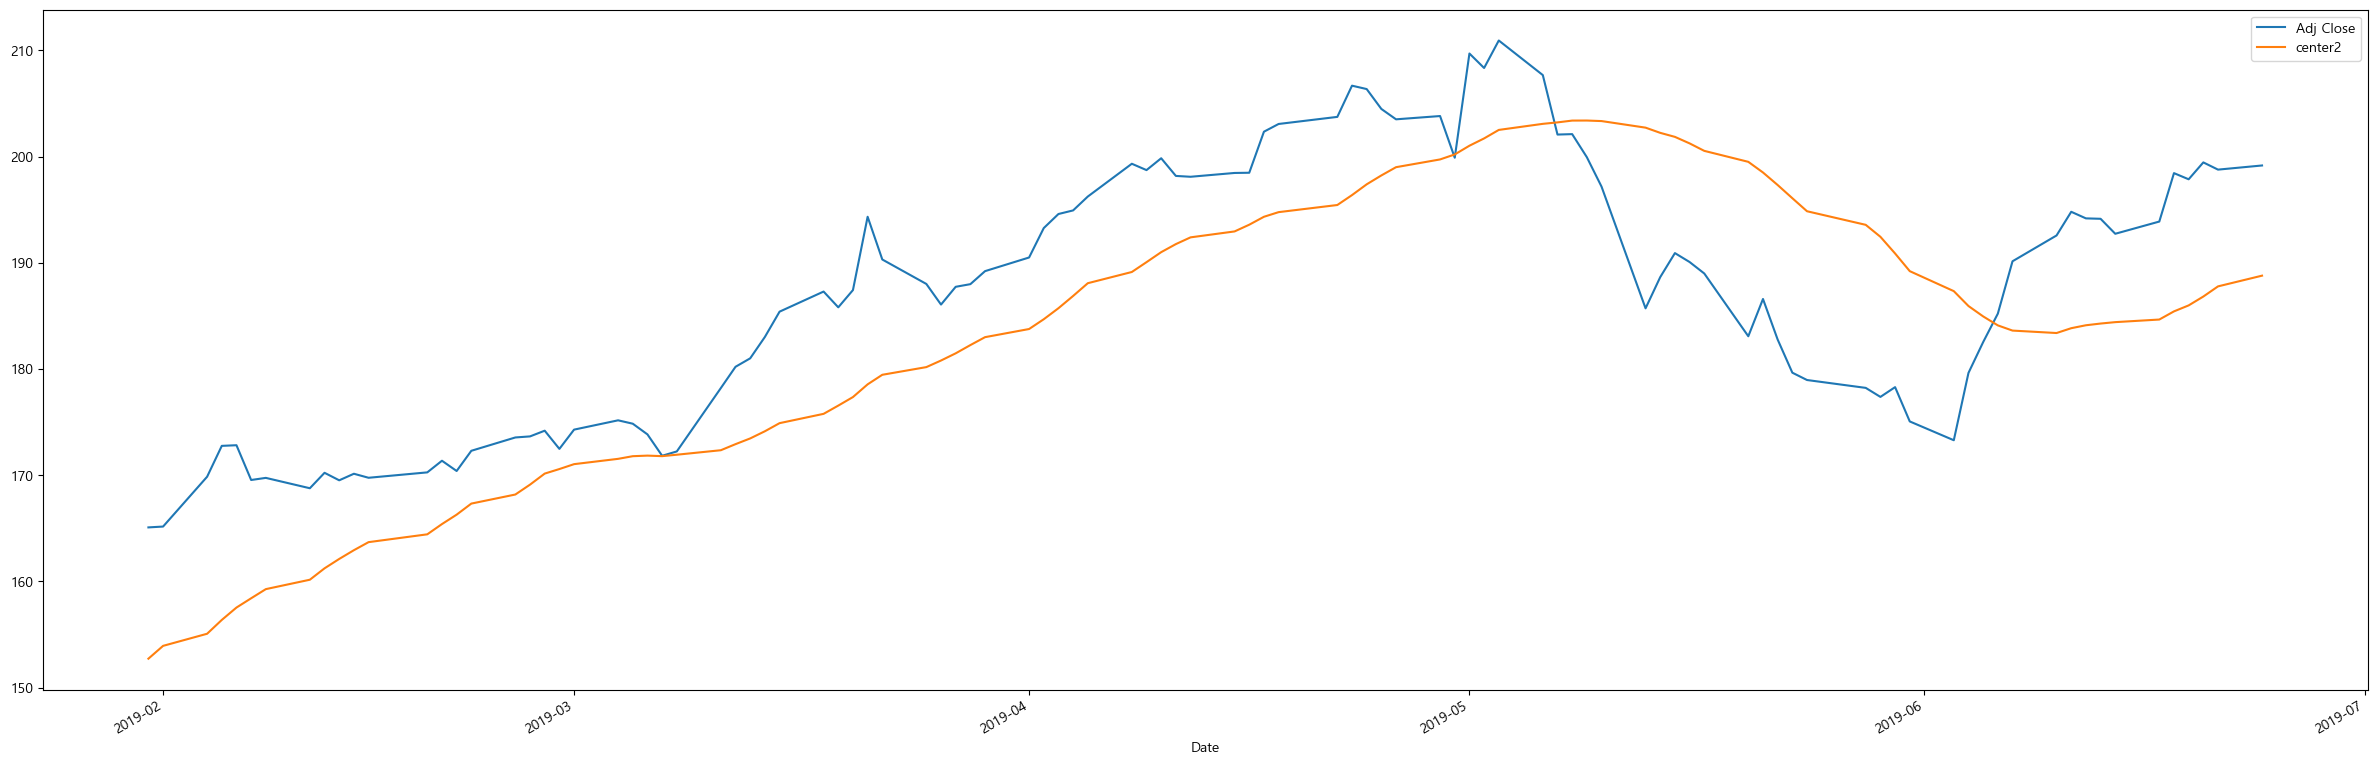

In [27]:
df2[['Adj Close', 'center2']].tail(100).plot(figsize=(30, 10))

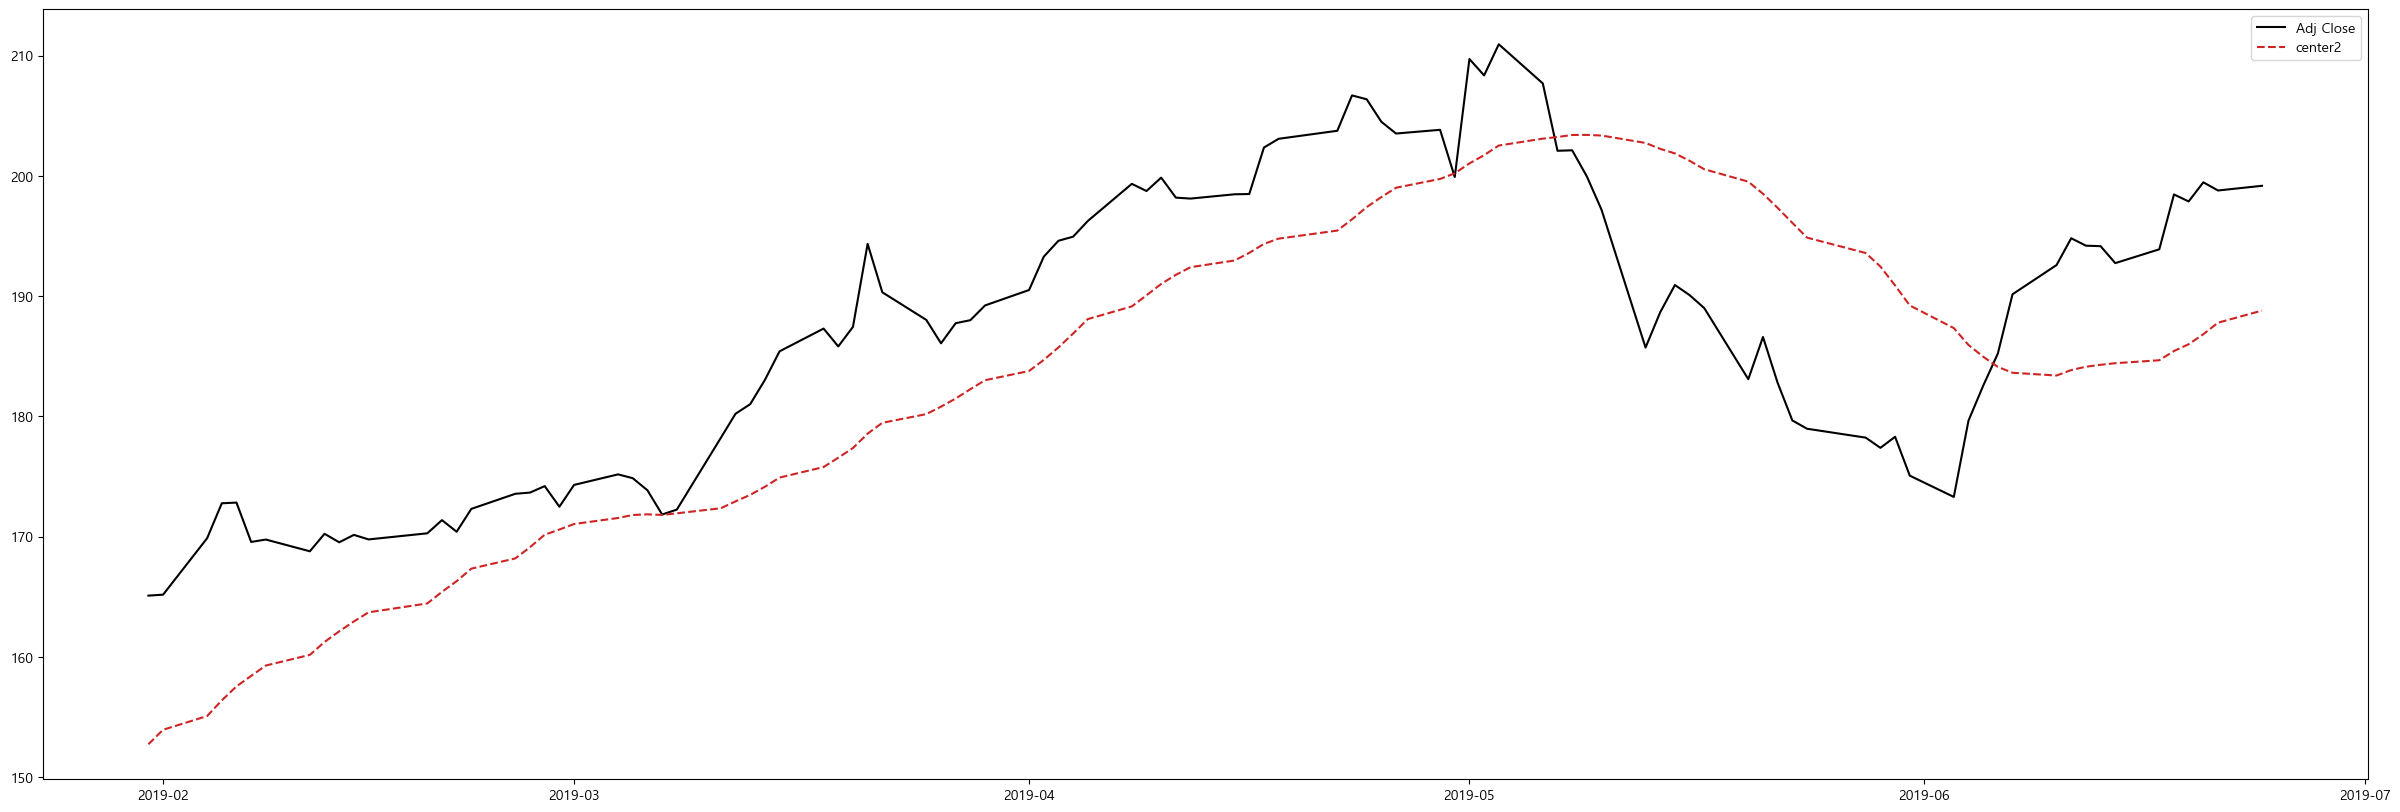

In [28]:
plt.figure(figsize=(30, 10))
plt.plot(df2.tail(100)['Adj Close'], color='#000000', label='Adj Close')
plt.plot(df2.tail(100)['center2'], '--', color="#cf2424", label='center2')
plt.legend()

plt.show()

- 상단밴드, 하단밴드
    - 상단 밴드 → 20일 이평선 + (2*20일 표준편차)
    - 하단 밴드 → 20일 이평선 - (2*20일 표준편차)

In [31]:
df2['ub'] = df2['center2'] + (2*df2['Adj Close'].rolling(20).std())
df2['lb'] = df2['center2'] - (2*df2['Adj Close'].rolling(20).std())

<Axes: xlabel='Date'>

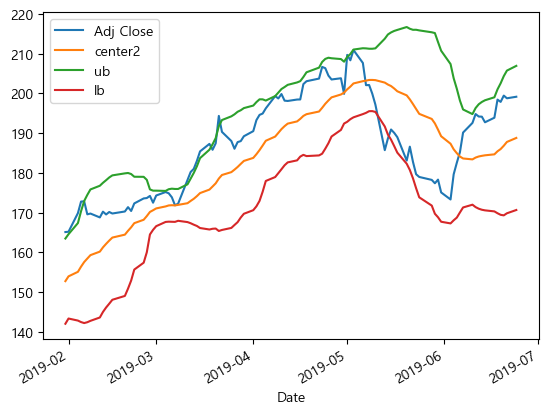

In [33]:
# 최근 100일치 데이터에서 상단밴드, 하단밴드, 이평선, 종가 그래프

df2.drop(['이동평균값'], axis=1).tail(100).plot()

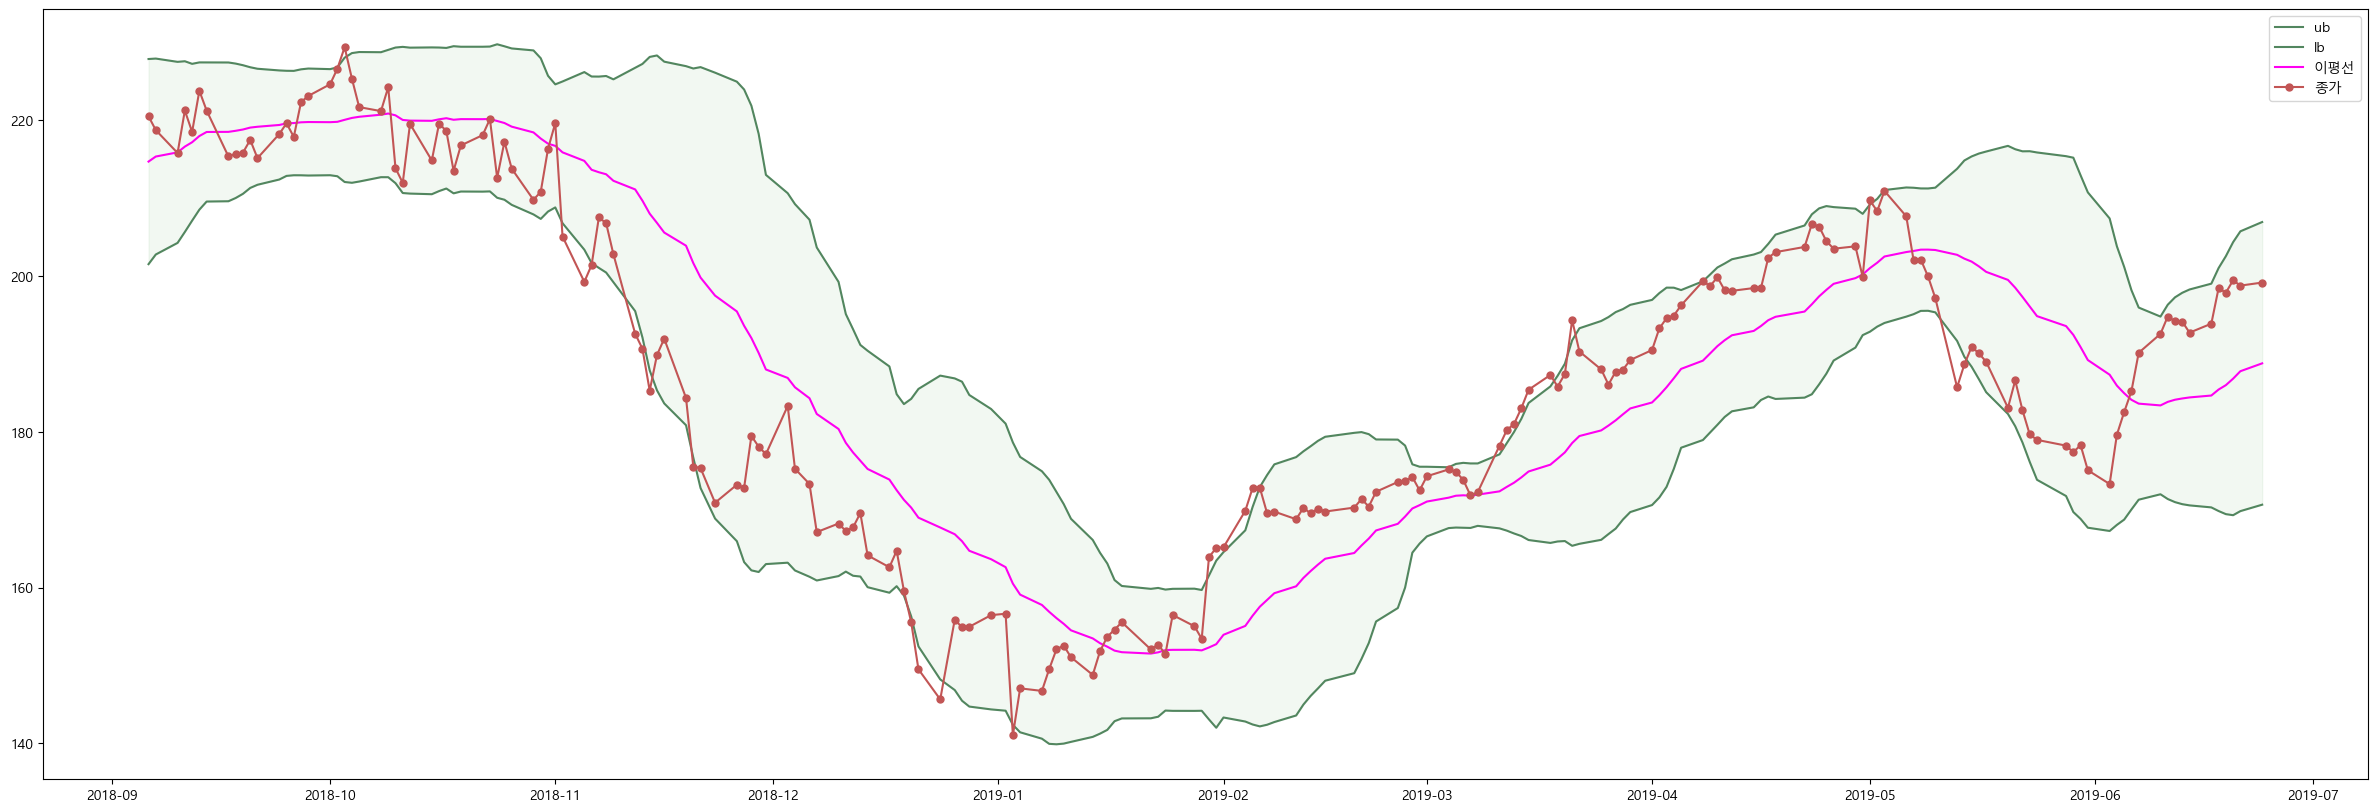

In [51]:
plt.figure(figsize=(30,10))
plt.plot(df2['ub'].tail(200), color="#52865F", label='ub')
plt.plot(df2['lb'].tail(200), color='#52865F', label='lb')
plt.plot(df2['center2'].tail(200), color="#FF00F2", label='이평선')
plt.plot(df2['Adj Close'].tail(200), marker = 'o', markersize=5, color="#C25555", label='종가')
plt.fill_between(df2.tail(200).index, df2['ub'].tail(200), df2['lb'].tail(200), color = 'green', alpha = 0.05)
plt.legend()
plt.show()